🚀 Firing up the Ensemble Pipeline on: mps

🔍 Processing Medical Scan: facture2.png
📊 [STAGE 1: CNN Spatial Classification Report]
   Diagnosis        : ⚠️ FRACTURE DETECTED
   Pixel Confidence : 88.30%
-----------------------------------------------------------------


Loading weights: 100%|██████████| 787/787 [00:00<00:00, 13234.90it/s]


💬 [STAGE 2: Contextual Visual Question Answering]
   Q: 'Is there a bone fracture in this X-ray image?'
   A: No

   Q: 'Is this condition curable?'
   A: Yes, there is a fracture.



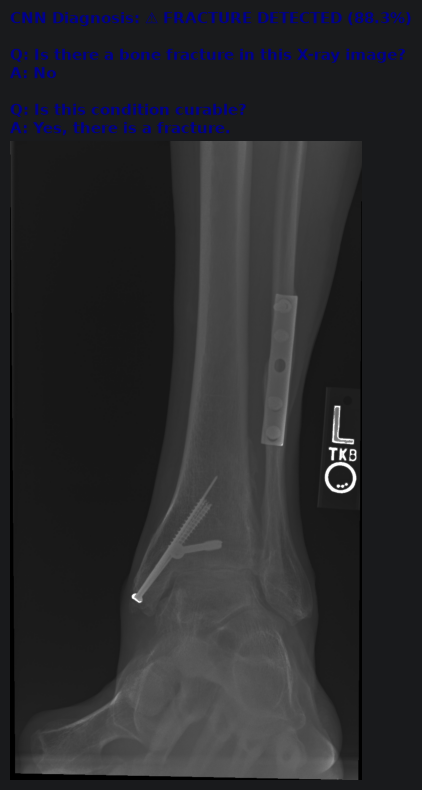

In [5]:
import os
import torch
from PIL import Image, ImageFile
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torchvision.models as models
from transformers import BlipProcessor, BlipForQuestionAnswering

# Prevents crashes if an image header is slightly corrupted
ImageFile.LOAD_TRUNCATED_IMAGES = True

# 1. Hardware Optimization for Mac (Apple Silicon / MPS)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"🚀 Firing up the Ensemble Pipeline on: {device}")

# Define absolute paths to your trained weights
CNN_MODEL_PATH = "/Users/saimohith/Documents/Sem-5/DL/BoneFractureQA/efficientnet_fracture.pth"
BLIP_MODEL_PATH = "/Users/saimohith/Documents/Sem-5/DL/BoneFractureQA/fine_tuned_blip"

class EfficientNetClassifier(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # Load the base architecture without pretrained weights (since we load our own next)
        self.model = models.efficientnet_b0()
        in_features = self.model.classifier[1].in_features
        self.model.classifier = torch.nn.Sequential(
            torch.nn.Dropout(p=0.3, inplace=True),
            torch.nn.Linear(in_features, 1)
        )
    def forward(self, x):
        return self.model(x)

def run_diagnostic_ensemble(image_path):
    print(f"\n🔍 Processing Medical Scan: {os.path.basename(image_path)}")
    print("=" * 65)

    if not os.path.exists(image_path):
        print(f"❌ File not found: {image_path}")
        return

    raw_image = Image.open(image_path).convert("RGB")

    # ─── STAGE 1: CNN SPATIAL CLASSIFICATION ───
    cnn_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    cnn_tensor = cnn_transform(raw_image).unsqueeze(0).to(device)

    loaded_cnn = EfficientNetClassifier().to(device)
    loaded_cnn.load_state_dict(torch.load(CNN_MODEL_PATH, map_location=device))
    loaded_cnn.eval()

    with torch.no_grad():
        logits = loaded_cnn(cnn_tensor)
        prediction_score = torch.sigmoid(logits).item()

    is_fractured = prediction_score > 0.5
    status = "⚠️ FRACTURE DETECTED" if is_fractured else "🟢 NO FRACTURE DETECTED"
    confidence = prediction_score if is_fractured else (1.0 - prediction_score)

    print(f"📊 [STAGE 1: CNN Spatial Classification Report]")
    print(f"   Diagnosis        : {status}")
    print(f"   Pixel Confidence : {confidence * 100:.2f}%")
    print("-" * 65)

    # ─── STAGE 2: VQA CONTEXTUAL INTERACTION ───
    loaded_processor = BlipProcessor.from_pretrained(BLIP_MODEL_PATH)
    loaded_blip = BlipForQuestionAnswering.from_pretrained(BLIP_MODEL_PATH).to(device)
    loaded_blip.eval()

    # Asking multiple questions to utilize our curable flag!
    questions = [
        "Is there a bone fracture in this X-ray image?",
        "Is this condition curable?"
    ]

    print(f"💬 [STAGE 2: Contextual Visual Question Answering]")
    answers = []

    for q in questions:
        inputs = loaded_processor(images=raw_image, text=q, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = loaded_blip.generate(**inputs, max_new_tokens=30)
            ans = loaded_processor.decode(outputs[0], skip_special_tokens=True).capitalize()
            answers.append(ans)
            print(f"   Q: '{q}'\n   A: {ans}\n")
    print("=" * 65)

    # Render Output Viewer
    plt.figure(figsize=(8, 8))
    plt.imshow(raw_image)

    display_text = f"CNN Diagnosis: {status} ({confidence*100:.1f}%)\n\n"
    display_text += f"Q: {questions[0]}\nA: {answers[0]}\n\n"
    display_text += f"Q: {questions[1]}\nA: {answers[1]}"

    plt.title(display_text, fontsize=11, fontweight='bold', color='darkblue', loc='left')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Point this to any image inside your test folder to run the entire pipeline!
    TEST_IMAGE = "/Users/saimohith/Downloads/facture2.png"

    run_diagnostic_ensemble(TEST_IMAGE)